## Read the following instructions carefully:
1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. 
1. Some questions require you to write your functions and answers in this jupyter notebook only. For these questions, you are free to add cells to this notebook.
1. For the other questions, you need to complete the required functions in the `hw2.py` script only. Only the functions in the `hw2.py` script are tested for this type of question.
1. In the function signatures include parameters with default values only. (`def example(a=1, b=2):`).
1. Submission includes a **zip** file that contains the `hw2.py` script as well as this notebook, with your ID as the file name. For example, `hw2_123456789_987654321.zip` if you submitted in pairs and `hw2_123456789.zip` if you submitted the exercise alone.

### Question 1 - Data exploration and visialization - practical

Load California dataset from sklearn.
Explore the data. 
Follow the instructions below and make sure to support your answers with proper outputs and plots.
When plotting, pay close attention to the range of the axis, and include axis labels and a title for the figure.

1. Describe the dataset. How many samples does it contain? How many features? What is the data type for each variable?
2. Produce a histogram and a boxplot of the HouseAge. describe the distribution.
3. Produce a correlation matrix of all the features. Are there any correlated features? Can you identify one feature with unusual behavior?
4. Select the 2 pairs of features with the highest correlation (positive or negative) and plot 2 scatter plots with marginal histograms (JointPlot). 
5. Produce a cumulative histogram of the HouseAge variable and add two vertical lines on the first and third quartile (on the cumulative count)
6. Identify and report 2 "interesting" trends in the data. No need to provide statistical confidence at this point. 

In [17]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
features = housing.feature_names
targets = housing.target_names[0]
X = df[features]
y = df[targets]
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Q1.1
Describe the dataset. How many samples does it contain? How many features? What is the data type for each variable?


In [18]:
print("dataset", housing.DESCR.splitlines()[0])
print('Description', housing.DESCR)
print("Number of sample",X.shape[0])
print("Number of features",X.shape[1])
print("Feature names ", features)
print("Targets name ", targets)
display(df.dtypes)

dataset .. _california_housing_dataset:
Description .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was der

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

So, as it can be seen is the cell above, the California housing dataset contains 20640 samples and 8 features.

 The code above also give an explanation for each features. 


Each features are float64 variables.


The target feature is MedHouseVal.

#### Q1.2
Produce a histogram and a boxplot of the HouseAge. describe the distribution.


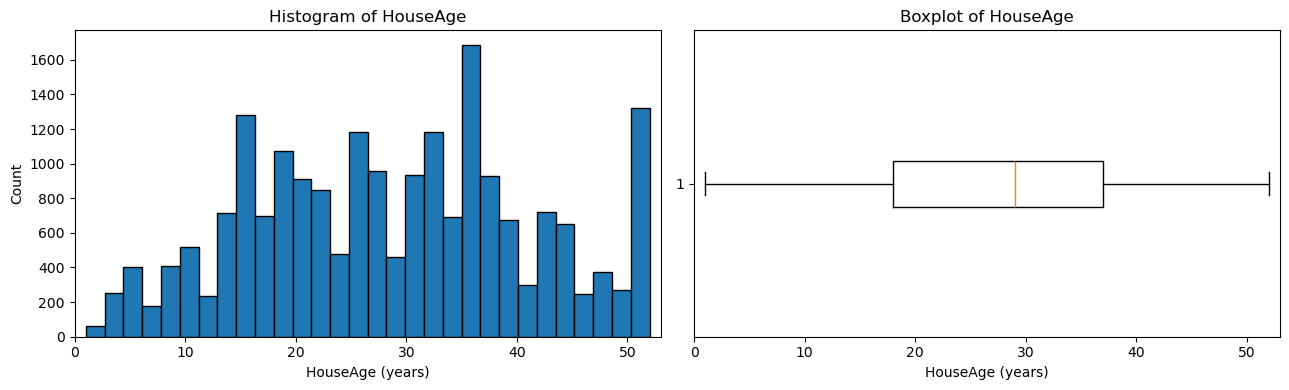

HouseAge summary:


count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64

In [22]:
house_age = df['HouseAge']
fig,ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(house_age, bins=30, edgecolor="black") # You can revise the bins parameter as much as you want. From multiple test, 30 seems to fit best.
ax[0].set_title("Histogram of HouseAge")
ax[0].set_xlabel("HouseAge (years)")
ax[0].set_ylabel("Count")
ax[0].set_xlim(house_age.min() - 1, house_age.max() + 1)

# Boxplot
ax[1].boxplot(house_age, vert=False)
ax[1].set_title("Boxplot of HouseAge")
ax[1].set_xlabel("HouseAge (years)")
ax[1].set_xlim(house_age.min() - 1, house_age.max() + 1)

plt.tight_layout()
plt.show()

print("HouseAge summary:")
display(house_age.describe())

Above are the histogram and plot distribution of the data. The boxplot extends from the first quartile to the third. We can see that the median age of an house is around 28-29 years old (see the orange line in the boxplot).
The newest house is around 1-2 years old while the oldest house are over 50 years old.

The distribution shows a notable spike at 52 years, which is likely a data collection artifact where houses older than 52 years were all recorded as 52. Otherwise, the distribution is roughly uniform across the age range, indicating a diverse mix of housing stock ages in California.

#### Q1.3
Produce a correlation matrix of all the features. Are there any correlated features? Can you identify one feature with unusual behavior?

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


Pairs with a correlation superior or equal to 0.65:
  Latitude vs Longitude   corr = -0.925
  AveRooms vs AveBedrms   corr = 0.848


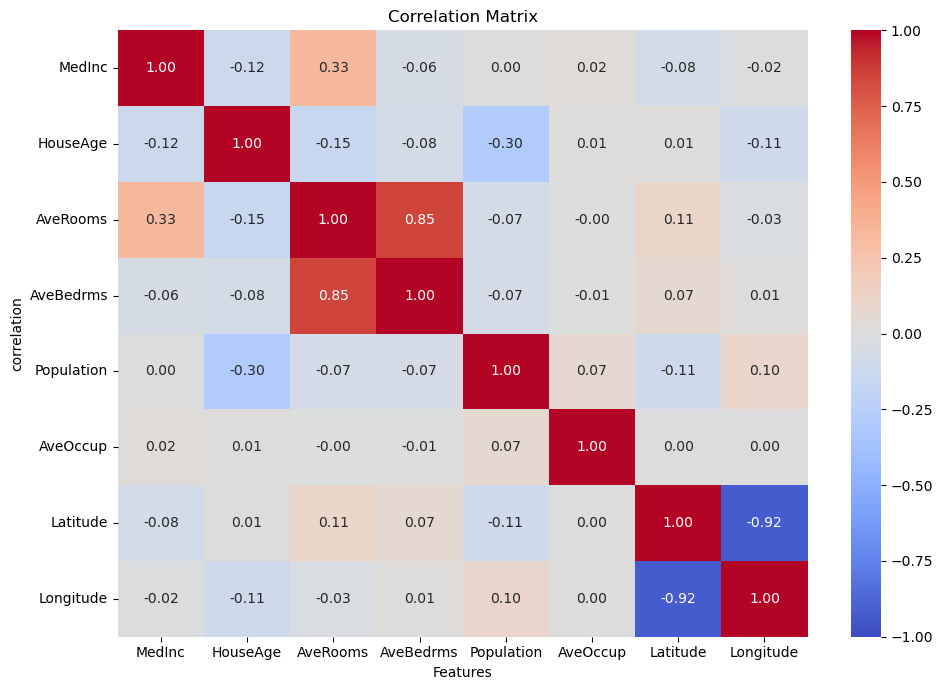

In [30]:
correlation = X.corr() # We want to compute the correlation matrix for the features only ( target excluded) otherwise it would be df.corr
display(correlation)

threshold = 0.65
pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        c = correlation.iloc[i, j]
        if abs(c) >= threshold:
            pairs.append((features[i], features[j], c))
pairs_sorted = sorted(pairs, key=lambda t: abs(t[2]), reverse=True) # sort the pairs with the highest positive or negative correlation in descending order (the key is the corr value hence t[2])
print(f"Pairs with a correlation superior or equal to {threshold}:")
for a, b, c in pairs_sorted:
    print(f"{a:>10} vs {b:<10}  corr = {c:.3f}")

plt.figure(figsize=(10,7))
sns.heatmap(correlation, annot=True, fmt='.2f',vmin=-1,vmax=1, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


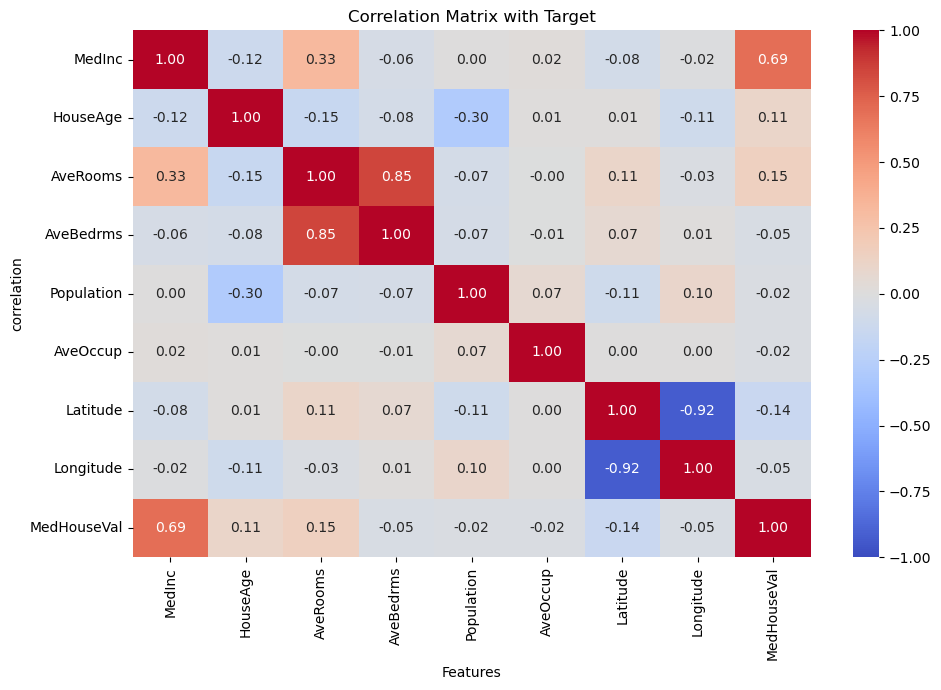

In [29]:
#Optional: Correlation Matrix with the targets
correlation_target = df.corr() #  correlation matrix for the features + target
display(correlation_target)

plt.figure(figsize=(10,7))
sns.heatmap(correlation_target, annot=True, fmt='.2f',vmin=-1,vmax=1,cmap='coolwarm')
plt.title("Correlation Matrix with Target")
plt.xlabel("Features")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

We ploted 2 heatmaps, one with the target feature (i.e. MedHouseVal) and one without. It only add one interesting correlation (MedHouseVal vs MedInc) to the heatmap without the target feature.


That said, we can see that 2 correlations distinguish themselves from the other. These are:
1. Average Bedrooms with Average Rooms with 0.85 (0.8476213257130424 to be precise) which is close to a perfect direct linear correlation. Houses with more rooms naturally have more bedrooms. This is intuitive.
2. Latitude and Longitude with -0.92 (-0.9246644339150366 to be precise) which is almost a perfect linear anti relationship i.e. an anti-correlation. This is California's geography: As you go north (↑ Latitude), you go east (↑ Longitude goes less negative). California runs NW to SE along the coast.


One unusual correlation would be the average occupency which can be considered as non related to any other features. Occupancy depends on demographics/culture, not physical house features.

#### Q1.4
Select the 2 pairs of features with the highest correlation (positive or negative) and plot 2 scatter plots with marginal histograms (JointPlot). 

Plotting: Latitude vs Longitude  (corr = -0.925)


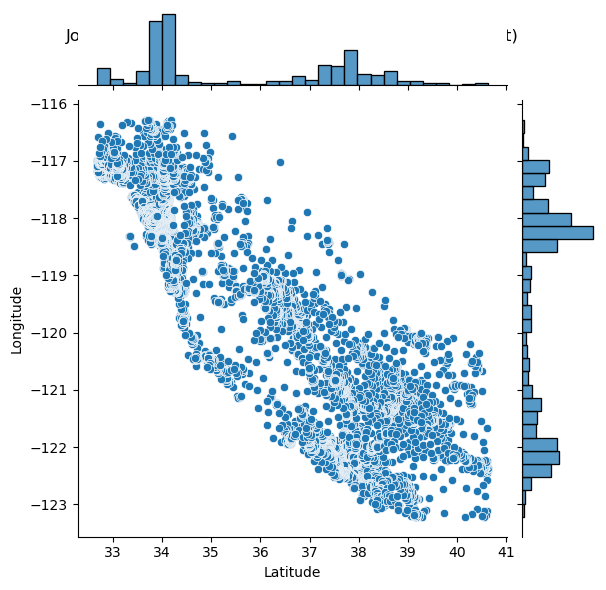

Plotting: AveRooms vs AveBedrms  (corr = 0.848)


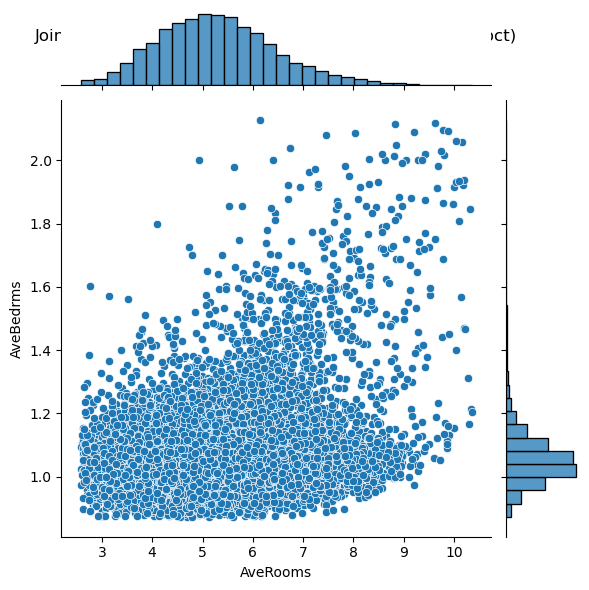

In [ ]:
# helper function
def jointplot_with_clipping(df, x, y, q=(0.01, 0.99)):
    """Scatter + marginal histograms, with axis clipping to reduce outlier dominance."""
    xlo, xhi = df[x].quantile(q[0]), df[x].quantile(q[1]) #1st and 99th percentiles
    ylo, yhi = df[y].quantile(q[0]), df[y].quantile(q[1])
    sub = df[(df[x].between(xlo, xhi)) & (df[y].between(ylo, yhi))].copy()

    r = sub[x].corr(sub[y])

    g = sns.jointplot(
        data=sub, x=x, y=y, kind="scatter",
        marginal_kws=dict(bins=30)
    )
    g.ax_joint.set_xlabel(x)
    g.ax_joint.set_ylabel(y)
    g.ax_joint.set_title(f"JointPlot: {x} vs {y} (clipped to {q[0]*100:.0f}-{q[1]*100:.0f}th pct)\nPearson r ≈ {r:.3f}",
                         pad=30)
    plt.show()

for x1, x2, c in pairs_sorted[:2]:
    print(f"Plotting: {x1} vs {x2}  (corr = {c:.3f})")
    jointplot_with_clipping(df, x1, x2, q=(0.01, 0.99))


The two plots show:
1. Latitude vs Longitude: Geographic clustering (California shape)
2. AveBedrms vs AveRooms: Linear relationship (more rooms → more bedrooms)

#### Q1.5
Produce a cumulative histogram of the HouseAge variable and add two vertical lines on the first and third quartile (on the cumulative count)

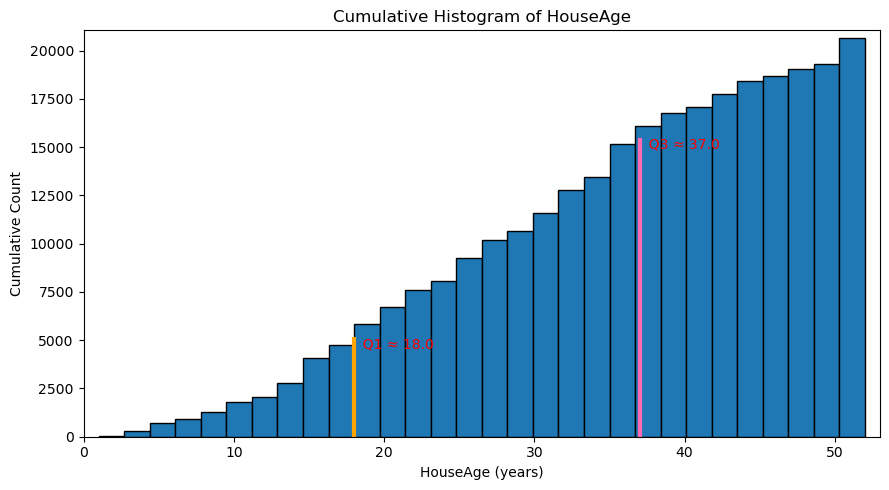

In [34]:
house_age = df["HouseAge"].values
num_of_house = len(house_age)

q1,q3 = np.quantile(house_age,[0.25,0.75])# first and third quartiles
plt.figure(figsize=(9, 5))
plt.hist(house_age, bins=30, cumulative=True, edgecolor="black")
plt.title("Cumulative Histogram of HouseAge")
plt.xlabel("HouseAge (years)")
plt.ylabel("Cumulative Count")
plt.vlines(q1, 0, 0.25*num_of_house, linewidth= 3,colors='orange')
plt.vlines(q3, 0, 0.75*num_of_house, linewidth= 3, color ='hotpink')


plt.text(q1, 0.25*num_of_house, f"  Q1 ≈ {q1:.1f}", va="top", color='red')
plt.text(q3, 0.75*num_of_house, f"  Q3 ≈ {q3:.1f}", va="top",color='red')

plt.xlim(min(house_age)-1, max(house_age)+1)
plt.ylim(0, num_of_house* 1.02)
plt.tight_layout()
plt.show()

* Cumulative histogram: Each bar shows "how many houses are ≤ this age"
* Q1 = 18 years: 25% of houses are 18 years old or younger
* Q3 = 37 years: 75% of houses are 37 years old or younger
* Interpretation: The middle 50% of houses (IQR) are between 18-37 years old

#### Q1.6
Identify and report 2 "interesting" trends in the data. No need to provide statistical confidence at this point. 

First Trend


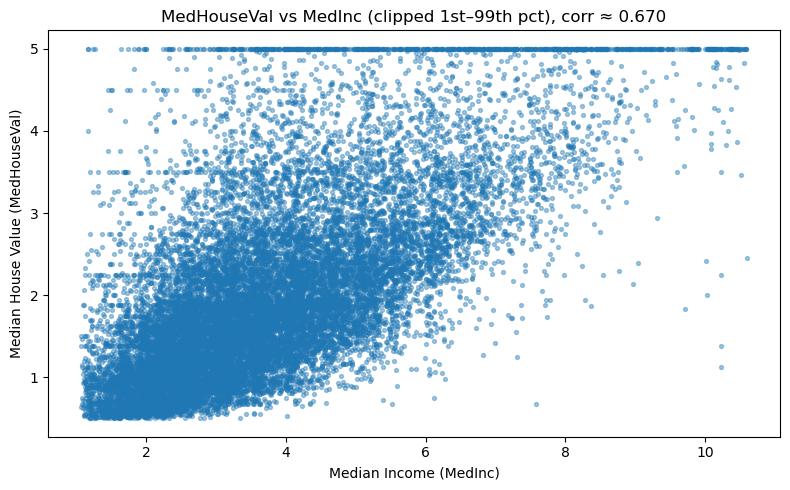

In [ ]:
print("First Trend")
trend_df = df.copy()

# Clip for readable axes
x = "MedInc"
t = targets

xlo, xhi = trend_df[x].quantile(0.01), trend_df[x].quantile(0.99)
tlo, thi = trend_df[t].quantile(0.01), trend_df[t].quantile(0.99)
sub = trend_df[trend_df[x].between(xlo, xhi) & trend_df[t].between(tlo, thi)]

r = sub[x].corr(sub[t])

plt.figure(figsize=(8, 5))
plt.scatter(sub[x], sub[t], s=8, alpha=0.4)
plt.title(f"{t} vs {x} (clipped 1st–99th pct), corr ≈ {r:.3f}")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value (MedHouseVal)")
plt.tight_layout()
plt.show()

When computing the correlation between the median income and and median house value, we see that we have a fairly high correlation value in contrasts of others correlation (see the heatmaps above).


However when plotting we observe that there is a significant spread in house value for the same level of income, meaning that income alone doesn't fully explain prices and other features (like the location for example) matter. 

Second Trend


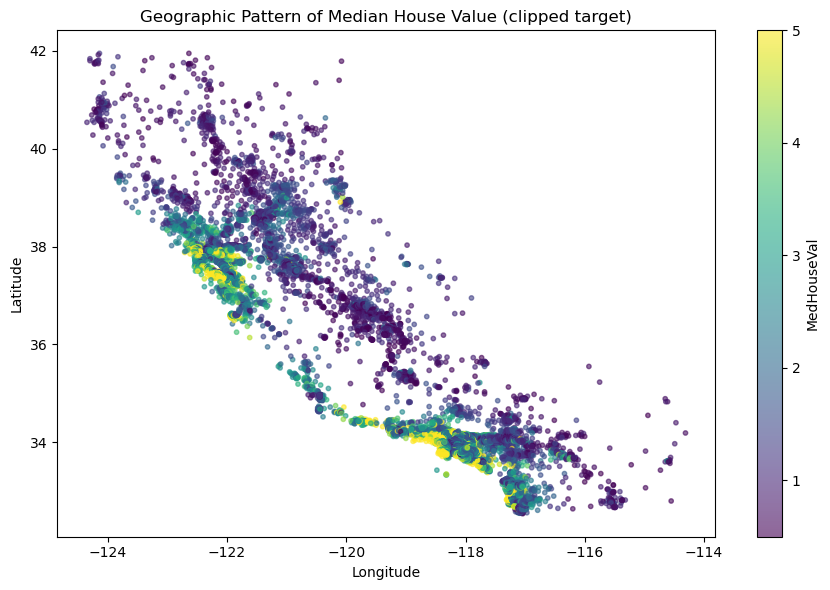

In [9]:
print("Second Trend")
# Clip target to improve visibility
geo = df.copy()
t = targets
tlo, thi = geo[t].quantile(0.01), geo[t].quantile(0.99)
geo = geo[geo[t].between(tlo, thi)]

plt.figure(figsize=(9, 6))
sc = plt.scatter(geo["Longitude"], geo["Latitude"], c=geo[t], s=10, alpha=0.6)
plt.title("Geographic Pattern of Median House Value (clipped target)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
cbar = plt.colorbar(sc)
cbar.set_label("MedHouseVal")
plt.tight_layout()
plt.show()


We can see that the house dataset moves west to east and north to south. We can compare this to the map of California and see that it's mostly moving around the coast.

More specifically, we observe clear geographic clustering of house values:
- **Coastal regions** (San Francisco Bay Area, Los Angeles, San Diego) show significantly higher median house values (brighter colors in the plot)
- **Inland areas** (Central Valley) display notably lower house values
- The **Bay Area** shows a distinct hot spot of high-value properties
- This pattern reflects the well-known premium for coastal California real estate, where proximity to the ocean, job centers, and urban amenities drives up housing prices

### Question 2 - Independence and conditional independence

#### 2.A
Let $\ X, Y \ $ and $Z$  be discrete random variables with $\ n, m \ $ and $k$ possible outcomes respectively.

How many parameters define the joint distribution of $\ X, Y \ $ and $Z$?

Complete the function `q2a` in `hw2.py` to answer this question.

In [ ]:
from hw2 import q2a

q2a()

#### 2.B
For the same random variables from the previous section, how many parameters define the joint distribution of $\ X, Y \ $ and $Z$ if we now know that they are independent?

Complete the function `q2b` in `hw2.py` to answer this question.

In [ ]:
from hw2 import q2b

q2b()

#### 2.C
For the same random variables from the previous section, how many parameters define the joint distribution of $\ X, Y \ $ and $Z$ if we now know that $X$ and $Y$ are conditionally independent given $Z$?

Complete the function `q2c` in `hw2.py` to answer this question.

In [ ]:
from hw2 import q2c

q2c()

### Question 3 - Gaussian mixtures – parameter estimation and generation 

Consider the data provided in GMD.csv
Assume that the data comes from a Gaussian mixture distribution (GMD) with $k=3$. Furthermore, assume that $\mu_{1}=4, \mu_{2}=9, \sigma_{1}=\sigma_{2}=0.5, \sigma_3=1.5$ and $w_2=0.25$.

Read the data and answer the following questions.

#### 3.A
Provide an estimate for the other parameters of the distribution using Algebra.

Write your solution in a Markdown cell below

What we know: 
$$
E(X) = \sum_{i} w_i \cdot E(X_i) \\
V(X) = \sum_{i} w_i \cdot \text{V}(X_i) + \sum_{i} w_i \cdot (E(X_i) - E(X))^2 \\
\sum_{i} w_i = 1
$$

Let's assume that the second column of GMD.csv is the data used for the distribution.

We want to find the values of the following parameters $\mu_{3}$ and $w_1, w_3$

Per the definition, $w_1 + w_2 + w_3 = 1$, so we have $w_1 + w_3 = 1 - w_2 = 0.75$ meaning that we have $w_3 = 0.75 - w_1$

From the data we get $E(X) \approx 12.2, V(X) \approx 17.57$


Thus we have:
$w_1 \cdot 4 + 0.25 \cdot 9 + (0.75 - w_1) \cdot \mu_3 = 12.2$


Meaning that $\mu_{3} = \frac{9.95 - 4 \cdot w_1}{0.75 - w_1}$


On the other hand we have:
$$
\sum_{i} w_i \cdot \text{V}(X_i) = w_1 \cdot 0.5^2 + 0.25 \cdot 0.5^2 + (0.75 - w_1) \cdot 1.5^2 \\
\sum_{i} w_i \cdot (E(X_i) - E(X))^2 =  w_1 \cdot (4 - 12.2)^2 + 0.25 \cdot (9 - 12.2)^2 + (0.75 - w_1) \cdot (\mu_3 - 12.2)^2 
$$
Altogether we have: $
w_1 \cdot 0.5^2 + 0.25 \cdot 0.5^2 + (0.75 - w_1) \cdot 1.5^2 + w_1 \cdot (4 - 12.2)^2 + 0.25 \cdot (9 - 12.2)^2 + (0.75 - w_1) \cdot (\mu_3 - 12.2)^2 = 17.57
$

After computing all of this we get: $\mu_3 \approx 15.1$, $w_1 \approx 0.123$ and $w_3 \approx 0.627$





In [37]:
df = pd.read_csv("GMD.csv", header=None)
x = df.iloc[:, 1].to_numpy(dtype=float)

N = x.size
m = x.mean()                 # empirical mean
v = x.var(ddof=0)            # empirical variance
s = x.std(ddof=0)            # empirical std

print("N =", N)
print("mean =", m)
print("var  =", v)
print("std  =", s)


N = 800
mean = 12.19884308211053
var  = 17.569039044801865
std  = 4.191543754370443


#### 3.B
Provide an estimate for the other parameters of the distribution using EM.

Your EM algorithm should support the fact that some of the parameter values are known in advance.

Complete the function `my_EM` in `hw2.py` to answer this question.

In [38]:
from hw2 import my_EM
mus, sigmas, ws = my_EM()
print('Estimation:')
for i, (mu, s,w) in enumerate(zip(mus, sigmas, ws)):
    print('{}: Mean: {:.2f}, Standard deviation: {:.2f}, Weight: {:.3f}'.format(i+1, mu, s, w))

Estimation:
1: Mean: 4.00, Standard deviation: 0.50, Weight: 0.125
2: Mean: 9.00, Standard deviation: 0.50, Weight: 0.250
3: Mean: 15.10, Standard deviation: 1.50, Weight: 0.625


#### 3.C
Now assume that the data comes from a Gaussian mixture distribution (GMD) with $k=4$.

The given data and parameters stay the same.

Provide an estimate for the other parameters of the distribution using EM. 

You need to use my_EM function from the previous section to answer this question. Your function should support any number of Gaussians and the specific known parameters in this question. 

In [39]:
from hw2 import my_EM

mus, sigmas, ws = my_EM(mus=np.array([4.0, 9.0, np.nan,np.nan]),
    sigmas=np.array([0.5, 0.5, 1.5, np.nan]),
    ws=np.array([np.nan, 0.25, np.nan,np.nan]))

print('Estimation:')
for i, (mu, s,w) in enumerate(zip(mus, sigmas, ws)):
    print('{}: Mean: {:.2f}, Standard deviation: {:.2f}, Weight: {:.3f}'.format(i+1, mu, s, w))

Estimation:
1: Mean: 4.00, Standard deviation: 0.50, Weight: 0.124
2: Mean: 9.00, Standard deviation: 0.50, Weight: 0.250
3: Mean: 11.05, Standard deviation: 1.50, Weight: 0.011
4: Mean: 15.13, Standard deviation: 1.47, Weight: 0.615


#### 3.D
Write a function for generating data for a GMM random variable.

Complete the function `q3d` in `hw2.py` to answer this question.


[1.82343879 1.37455759 2.81212562 2.85392868 4.44391103 4.24837071
 2.05973271 2.51125719 3.29685464 2.17503461 1.77036059 1.52049638
 1.17198679 4.2713044  3.86164699 4.47888487 4.01288346 2.30054409
 1.95794074 4.03500565 1.18723057 1.16192678 4.04373989 1.9919442
 1.22354994 4.28609505 3.77894357 4.46221116 1.74763586 2.60258978
 1.58395095 3.83630344 4.37836803 4.07918063 1.66333061 3.74978896
 3.89532759 1.39500329 0.77624827 2.22454155 1.94790998 1.67926002
 4.0051555  2.06587899 1.91589551 3.26626406 2.20909477 2.03668374
 1.46109718 2.04768853 1.78426525 1.7537843  1.80329177 2.59450999
 2.30266776 0.93308514 3.46081098 3.42717968 3.92112267 4.05361603
 3.99356476 2.48983923 4.49309869 1.82770702 4.19301602 2.00823515
 4.59849577 4.40203056 2.55790018 2.66314597 2.1580216  3.68772796
 4.09921689 2.62316071 2.52252461 3.75949871 4.07020798 2.0862802
 4.15261695 3.9511922  2.12789868 1.2273669  1.52795656 1.3372201
 4.27901061 0.90579604 4.09573497 3.63034548 2.6603251  1.8011415

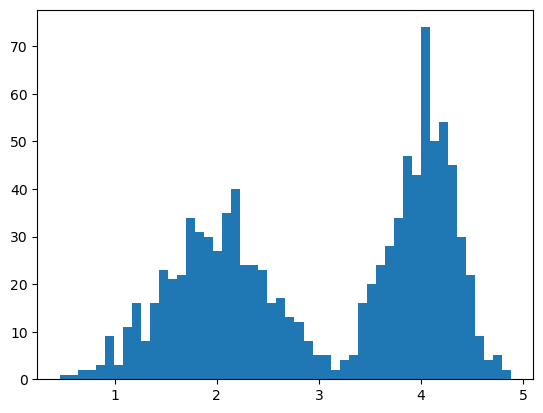

In [40]:
from hw2 import q3d

#X = q3d()

data = q3d(mus=[2,4], sigmas=[0.5, 0.3], ws=[0.5, 0.5])
print(data)
plt.hist(data, bins=50)
plt.show()

### Question 4 - Normally distributed salaries

The annual salaries of employees in a large Randomistan company are approximately normally distributed with a mean of 75,000 RCU and a standard deviation of 37,500 RCU.

Complete the functions in `hw2.py` to answer the following question.

#### 4.A
What percent of people earn less than 50,000 RCU?

In [2]:
from hw2 import q4a

X = q4a()

#### 4.B
What percent of people earn between 45,000 RCU and 65,000 RCU?

In [ ]:
from hw2 import q4b

X = q4b()

#### 4.C
What percent of people earn more than 85,000 RCU?

In [4]:
from hw2 import q4c

X = q4c()

#### 4.D
The company has 1000 employees. How many employees in the company do you expect to earn more than 140,000 RCU?

In [3]:
from hw2 import q4d

X = q4d()

### Question 5 - Coupon collector

Let $T_{N}$ denote the waiting time for full single coupon collection with N different equiprobable coupon types.


#### 5.A
Write code to compute the exact value of $E(T_{N})$

Complete the function `CC_Expected` in `hw2.py` to answer the following question.

In [ ]:
from hw2 import CC_Expected

CC_Expected()

#### 5.B
Write code to compute the exact value of $V(T_{N})$

Complete the function `CC_Variance` in `hw2.py` to answer the following question.

In [ ]:
from hw2 import CC_Variance

CC_Variance()

#### 5.C
Write code to exactly compute $P(T_{10}>30)$

Complete the function `CC_T_Steps` in `hw2.py` to answer the following question.

In [ ]:
from hw2 import CC_T_Steps

CC_T_Steps()

#### 5.D
Let $S_N$ denote the waiting time until $N$ different coupons are collected **twice**.

Write code to exactly compute $P(S_{10}>30)$

Complete the function `CC_S_Steps` in `hw2.py` to answer the following question.

In [ ]:
from hw2 import CC_S_Steps

CC_S_Steps()

### Question 6 - Heavy Tailed Distributions and the Exponential Distribution

### Heavy Tailed Distributions

Recall the definition of Heavy Tailed distribution from the lectures.

*A distribution is said to have a heavy right tail if its tail probabilities vanish slower than any exponential*
$$ \forall t>0, \lim_{x\to\infty} e^{tx}P(X>x)=\infty $$

Does the standard log-normal distribution have a heavy right tail? prove your answer.

### Answer: Yes, the standard log-normal distribution has a heavy right tail.

**Proof:**

Let $X \sim \text{LogNormal}(0, 1)$, which means $\ln X \sim N(0, 1)$.

**Step 1:** Express $P(X > x)$ in terms of the standard normal distribution.

Since $\ln X \sim N(0, 1)$, we have:
$$P(X > x) = P(\ln X > \ln x) = P(Z > \ln x) = 1 - \Phi(\ln x)$$
where $Z \sim N(0, 1)$ and $\Phi$ is the standard normal CDF.

**Step 2:** Use the tail approximation for the standard normal distribution.

For large $y$, the standard normal tail behaves as:
$$1 - \Phi(y) \sim \frac{1}{y\sqrt{2\pi}} e^{-y^2/2}$$

Therefore, for large $x$:
$$P(X > x) \sim \frac{1}{\ln x \sqrt{2\pi}} e^{-(\ln x)^2/2}$$

**Step 3:** Compute $\lim_{x \to \infty} e^{tx} P(X > x)$ for any $t > 0$.

$$\lim_{x \to \infty} e^{tx} P(X > x) = \lim_{x \to \infty} e^{tx} \cdot \frac{1}{\ln x \sqrt{2\pi}} e^{-(\ln x)^2/2}$$

$$= \lim_{x \to \infty} \frac{1}{\ln x \sqrt{2\pi}} \exp\left(tx - \frac{(\ln x)^2}{2}\right)$$

**Step 4:** Analyze the exponent.

As $x \to \infty$:
- The term $tx$ grows exponentially (like $e^{\ln x} = x$ raised to power $t$)
- The term $\frac{(\ln x)^2}{2}$ grows only polynomially in $\ln x$

More precisely, for any $t > 0$:
$$\lim_{x \to \infty} \left(tx - \frac{(\ln x)^2}{2}\right) = \infty$$

This is because $tx$ dominates $(\ln x)^2$ as $x \to \infty$.

**Step 5:** Conclusion.

Since the exponent goes to infinity:
$$\lim_{x \to \infty} e^{tx} P(X > x) = \lim_{x \to \infty} \frac{1}{\ln x \sqrt{2\pi}} \cdot e^{\infty} = \infty$$

This holds for **any** $t > 0$.

Therefore, by the definition of heavy-tailed distributions, **the standard log-normal distribution has a heavy right tail**.